Script to test new SSP population data (version 3.0) provided by Jonathan. 

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt      # visualisation

In [8]:
# read netcdf data using xarray
def read_netcdf(filepath):
    dataset = xr.open_dataset(filepath)
    return dataset

# POPULATION DENSITY DATA
gpopd_30min_fp = r"X:\user\doelmanj\ScenDevelopment\ScenarioMIP\3_IMAGE_land\scen\{}\netcdf\GPOPD_30MIN.NC"

gpopd_30min_ssp1 = read_netcdf(gpopd_30min_fp.format('SSP1_M'))
gpopd_30min_ssp2 = read_netcdf(gpopd_30min_fp.format('SSP2_CP'))
gpopd_30min_ssp3 = read_netcdf(gpopd_30min_fp.format('SSP3_H'))
gpopd_30min_ssp5 = read_netcdf(gpopd_30min_fp.format('SSP5_H'))

# AREA DATA
area_gc = read_netcdf(r'X:\IMAGE\data\processed\IMAGE\IMAGE_INPUT\unf_5min\netcdf\GAREACELLNOWATER_30MIN.NC')

# REGION DATA
image_regions = read_netcdf(r'X:\user\crassierc\code\cooling\CoolingDegreeDays\Gridded_IMAGE_data\GREG_30MIN.NC')

In [9]:
def calculate_population(gpopd_dataset, area_dataset, year):

    # Select the specified year for both datasets
    time = pd.Timestamp(f"{year}-01-01")
    # pop_density = gpopd_dataset.GPOPD.sel(time=time, method='nearest')
    pop_density = gpopd_dataset.GPOPD_30MIN.sel(time=time, method='nearest')
    area = area_dataset.GAREACELLNOWATER_30MIN.sel(time=time, method='nearest')
    
    # Calculate population by multiplying density by area
    population = pop_density * area
    
    # Print some verification info
    # total_pop = population.sum().values / 1e9
    # print(f"\nVerification for year {year}:")
    # print(f"Total population: {total_pop:.3f} billion")
    
    return population


Population Comparison:
-----------------------------------
Year      SSP1        SSP2        SSP3        SSP5        
-----------------------------------
1970            4.06      4.06      4.06      4.06
1980            4.43      4.43      4.43      4.43
1990            5.30      5.30      5.30      5.30
2000            6.13      6.13      6.13      6.13
2010            6.97      6.97      6.97      6.97
2020            7.82      7.82      7.82      7.82
2030            8.48      8.54      8.58      8.48
2040            8.93      9.16      9.38      8.93
2050            9.22      9.64     10.11      9.22
2060            9.30      9.97     10.80      9.30
2070            9.20     10.15     11.44      9.20
2080            8.95     10.19     12.02      8.96
2090            8.56     10.12     12.57      8.58
2100            8.07      9.95     13.10      8.09


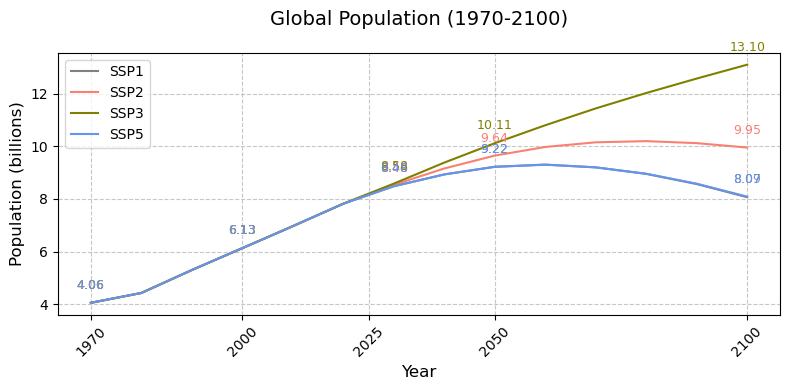

In [11]:
def plot_population_trends(datasets, dataset_names, area, styles=None):

    # Default styles if none provided
    if styles is None:
        styles = [
            {'color': 'gray', 'linestyle': '-'},
            {'color': 'salmon', 'linestyle': '-'},
            {'color': 'olive', 'linestyle': '-'},
            {'color': 'cornflowerblue', 'linestyle': '-'}
        ]
    
    # Get all years from 1970 to 2100
    years = range(1970, 2101, 10)
    
    # Dictionary to store populations for all datasets
    all_populations = {name: [] for name in dataset_names}
    
    # Calculate populations for all datasets
    for year in years:
        for dataset, name in zip(datasets, dataset_names):
            pop = calculate_population(dataset, area, year)
            total_pop = pop.sum().values / 1e9  # Convert to billions
            all_populations[name].append(total_pop)
    
    # Create the plot
    plt.figure(figsize=(8, 4))
    
    # Plot each dataset
    for (name, populations), style in zip(all_populations.items(), styles):
        plt.plot(years, populations, 
                label=name,
                **style)
        
        # Add data labels for key years
        for i, (year, pop) in enumerate(zip(years, populations)):
            if year in [1970,2000,2030,2050,2100]:
                plt.annotate(f'{pop:.2f}', 
                            (year, pop), 
                            textcoords="offset points", 
                            xytext=(0, 10), 
                            ha='center',
                            fontsize=9,
                            color=style['color'])
    
    # Customize the plot
    plt.title('Global Population (1970-2100)', fontsize=14, pad=20)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Population (billions)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=10)
    plt.xticks([1970,2000,2025,2050,2100], rotation=45)
    plt.tight_layout()
    
    # Print comparison table
    print("\nPopulation Comparison:")
    print("-" * 35)
    header = f"{'Year':<10}"
    for name in dataset_names:
        header += f"{name:<12}"
    print(header)
    print("-" * 35)
    
    for i, year in enumerate(years):
        row = f"{year:<10}"
        for name in dataset_names:
            row += f"{all_populations[name][i]:>10.2f}"
        print(row)
    
    return all_populations, years

# Plot the datasets
populations, years = plot_population_trends(
    datasets=[
        gpopd_30min_ssp1,
        gpopd_30min_ssp2,
        gpopd_30min_ssp3,
        gpopd_30min_ssp5
        ],
    dataset_names=[
        'SSP1',
        'SSP2',
        'SSP3',
        'SSP5'
        ],
    area = area_gc)


In [13]:
def calculate_regional_population(population_data, region_data):

    # Convert to numpy arrays for faster computation
    pop_array = population_data.values
    reg_array = region_data.GREG_30MIN.isel(time=0).values
    
        # Print debug information
    print("\nRegional Calculation Debug:")
    print(f"Population array shape: {pop_array.shape}")
    print(f"Region array shape: {reg_array.shape}")
    
    # Initialize results dictionary
    regional_populations = {}
    
    # Calculate for each region
    for region_num in range(1, 28):
        mask = (reg_array == region_num)
        regional_pop = np.sum(pop_array[mask])
        regional_populations[region_num] = regional_pop
        
    return regional_populations

In [15]:
def get_regional_population(gpopd_dataset, area_dataset, region_dataset, year):

    # First calculate population per grid cell
    population = calculate_population(gpopd_dataset, area_dataset, year)

    # Then calculate population per region
    regional_pops = calculate_regional_population(population, region_dataset)
    
    # Print results in a formatted way
    print(f"\nRegional Populations for {year}:")
    print("-" * 40)
    total_pop = 0
    for region, pop in regional_pops.items():
        pop_millions = pop / 1e6
        print(f"Region {region:1d}: {pop_millions:,.2f} million")
        total_pop += pop
    
    print("-" * 40)
    print(f"Total Population: {total_pop/1e9:,.3f} billion")
    
    return regional_pops

# Example usage for a single year:
year = 2100
pops_2020 = get_regional_population(gpopd_30min_ssp2, area_gc, image_regions, year)


Regional Calculation Debug:
Population array shape: (360, 720)
Region array shape: (360, 720)

Regional Populations for 2100:
----------------------------------------
Region 1: 44.72 million
Region 2: 408.50 million
Region 3: 144.19 million
Region 4: 106.04 million
Region 5: 182.23 million
Region 6: 235.63 million
Region 7: 333.03 million
Region 8: 1,823.16 million
Region 9: 864.18 million
Region 10: 60.73 million
Region 11: 425.04 million
Region 12: 83.69 million
Region 13: 85.64 million
Region 14: 36.34 million
Region 15: 114.50 million
Region 16: 138.47 million
Region 17: 416.40 million
Region 18: 1,421.65 million
Region 19: 45.84 million
Region 20: 825.34 million
Region 21: 425.47 million
Region 22: 290.41 million
Region 23: 74.86 million
Region 24: 45.77 million
Region 25: 806.60 million
Region 26: 511.52 million
Region 27: 0.00 million
----------------------------------------
Total Population: 9.950 billion


In [16]:
def analyze_population_by_region(gpopd_dataset, area_data, region_data, years):

    results = {}
    
    for year in years:
        # Calculate population for the year
        population = calculate_population(gpopd_dataset, area_data, year)
        
        # Calculate regional populations
        regional_pops = calculate_regional_population(population, region_data)
        
        # Store results
        results[year] = regional_pops
        
        # Print results for this year
        print(f"\nRegional Populations in {year}:")
        print("-" * 40)
        total_pop = 0
        for region, pop in regional_pops.items():
            pop_millions = pop / 1e6
            print(f"Region {region:2d}: {pop_millions:,.2f} million")
            total_pop += pop
        
        print("-" * 40)
        print(f"Total Population: {total_pop/1e9:,.3f} billion")
    
    return results